< 시각화 - 데이터 탐색 실습 >

In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt

# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# BostonHousing.csv 파일 로드
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# 데이터 크기
display(df.shape)

# 정보
display(df.info())

# 기술통계
display(df.describe())

# 결측치
display(df.isnull().sum())

# 변수명
display(df.columns)

(506, 14)

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [ ]:
# 필요한 변수만 선택 후 새로운 데이터프레임에 복사
df2 = df[["crim", "rm", "dis", "tax", "medv"]]

display(df2.head())

,crim,rm,dis,tax,medv
0,0.00632,6.575,4.0900,296,24.0
1,0.02731,6.421,4.9671,242,21.6
2,0.02729,7.185,4.9671,242,34.7
3,0.03237,6.998,6.0622,222,33.4
4,0.06905,7.147,6.0622,222,36.2


In [5]:
# medv 기준으로 등급 생성
# grade 열을 먼저 생성 : 기본값으로 전부 "하"
df2["grade"] = "하"

# medv가 17 이상이면 중
df2.loc[df2["medv"] >= 17, "grade"] = "중"

# medv가 25 이상이면 상
df2.loc[df2["medv"] >= 25, "grade"] = "상"


# category 타입으로 변환
df2["grade"] = df2["grade"].astype("category")

display(df2.head())
display(df2.tail())
display(df2.dtypes)

df2.grade.value_counts()

,crim,rm,dis,tax,medv,grade
0,0.00632,6.575,4.0900,296,24.0,중
1,0.02731,6.421,4.9671,242,21.6,중
2,0.02729,7.185,4.9671,242,34.7,상
3,0.03237,6.998,6.0622,222,33.4,상
4,0.06905,7.147,6.0622,222,36.2,상


,crim,rm,dis,tax,medv,grade
501,0.06263,6.593,2.4786,273,22.4,중
502,0.04527,6.120,2.2875,273,20.6,중
503,0.06076,6.976,2.1675,273,23.9,중
504,0.10959,6.794,2.3889,273,22.0,중
505,0.04741,6.030,2.5050,273,11.9,하


crim      float64
rm        float64
dis       float64
tax         int64
medv      float64
grade    category
dtype: object

grade
중    248
상    132
하    126
Name: count, dtype: int64

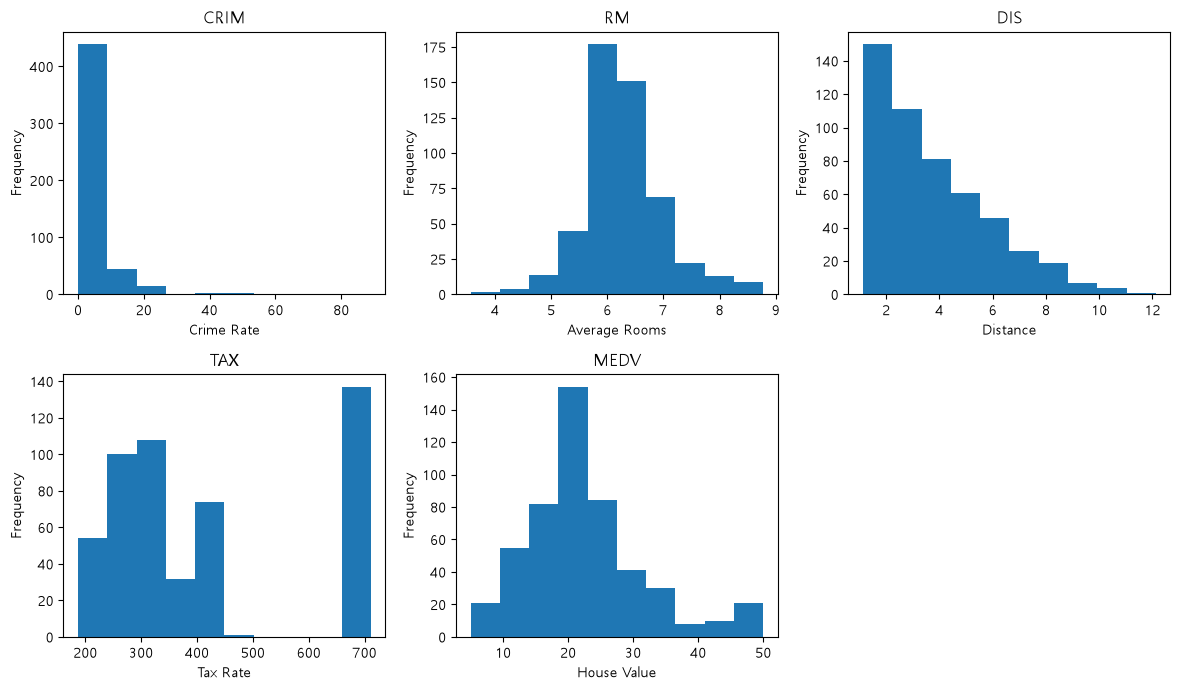

In [6]:
# 평균(히스토그램) 탐색

fig = plt.figure(figsize=(12, 7))

# 1행 1열
axes1 = fig.add_subplot(2, 3, 1)
axes1.hist(df2["crim"])
axes1.set_title("CRIM")
axes1.set_xlabel("Crime Rate")
axes1.set_ylabel("Frequency")

# 1행 2열
axes2 = fig.add_subplot(2, 3, 2)
axes2.hist(df2["rm"])
axes2.set_title("RM")
axes2.set_xlabel("Average Rooms")
axes2.set_ylabel("Frequency")

# 1행 3열
axes3 = fig.add_subplot(2, 3, 3)
axes3.hist(df2["dis"])
axes3.set_title("DIS")
axes3.set_xlabel("Distance")
axes3.set_ylabel("Frequency")

# 2행 1열
axes4 = fig.add_subplot(2, 3, 4)
axes4.hist(df2["tax"])
axes4.set_title("TAX")
axes4.set_xlabel("Tax Rate")
axes4.set_ylabel("Frequency")

# 2행 2열
axes5 = fig.add_subplot(2, 3, 5)
axes5.hist(df2["medv"])
axes5.set_title("MEDV")
axes5.set_xlabel("House Value")
axes5.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

탐색 예시)

# CRIM
# 대부분 낮은 값에 집중되어 있다.
# 일부 매우 큰 값이 있어 오른쪽으로 치우친 분포를 보인다.

# RM
# 평균 방 개수는 주로 5~7개 정도에 집중되어 있다.
# 비교적 종 모양에 가까운 분포다.

# DIS
# 주로 2~6 정도의 값에 분포한다.
# 극단적으로 큰 값은 많지 않다.

# TAX
# 특정 세율 구간에 데이터가 많이 몰려 있다.
# 값의 분포가 고르게 퍼져 있지 않고 일부 구간에 집중되어 있다.

# MEDV
# 주택 가격은 주로 15~30 정도에 많이 분포한다.
# 높은 가격대에도 데이터가 있으며, 50에서 값이 제한된 현상이 나타난다.

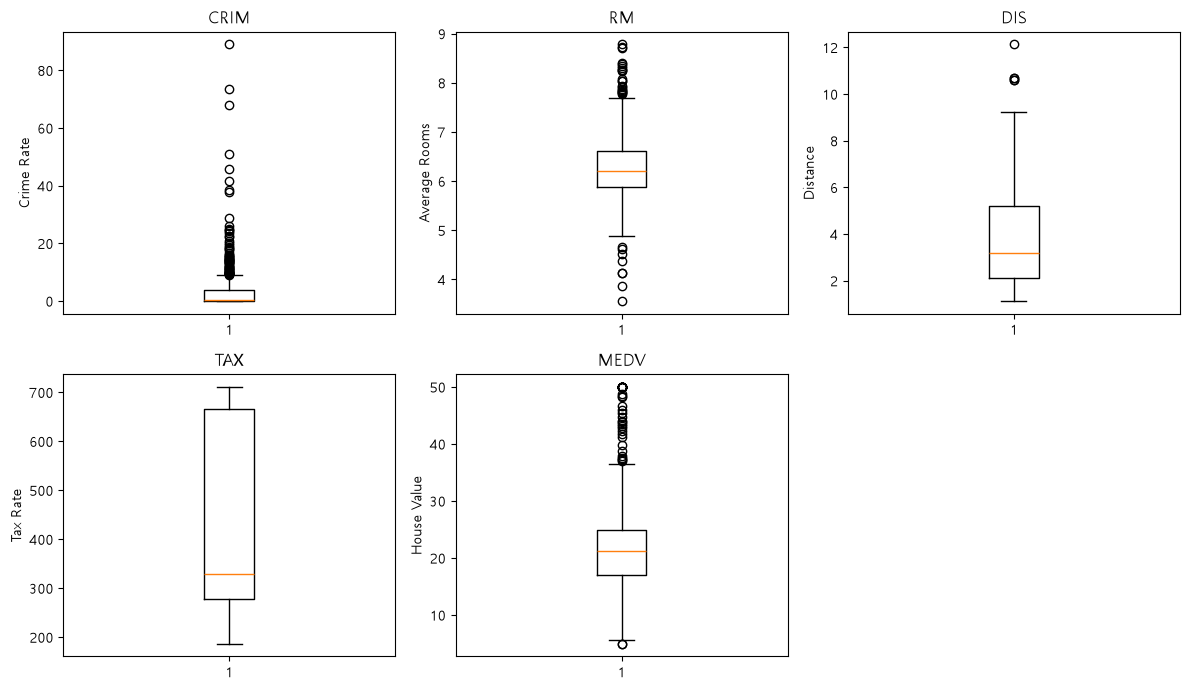

In [7]:
# 중앙값(박스플롯) 탐색

fig = plt.figure(figsize=(12, 7))

axes1 = fig.add_subplot(2, 3, 1)
axes1.boxplot(df2["crim"])
axes1.set_title("CRIM")
axes1.set_ylabel("Crime Rate")

axes2 = fig.add_subplot(2, 3, 2)
axes2.boxplot(df2["rm"])
axes2.set_title("RM")
axes2.set_ylabel("Average Rooms")

axes3 = fig.add_subplot(2, 3, 3)
axes3.boxplot(df2["dis"])
axes3.set_title("DIS")
axes3.set_ylabel("Distance")

axes4 = fig.add_subplot(2, 3, 4)
axes4.boxplot(df2["tax"])
axes4.set_title("TAX")
axes4.set_ylabel("Tax Rate")

axes5 = fig.add_subplot(2, 3, 5)
axes5.boxplot(df2["medv"])
axes5.set_title("MEDV")
axes5.set_ylabel("House Value")

plt.tight_layout()
plt.show()

탐색 예시)

# CRIM
# 상자 위쪽으로 많은 이상치가 나타난다.
# 일부 지역의 범죄율이 매우 높아 오른쪽으로 치우친 분포다.

# RM
# 이상치가 일부 존재한다.
# 대부분의 값은 비교적 좁은 범위에 분포한다.

# DIS
# 일부 높은 값이 이상치로 나타난다.
# 중앙값을 기준으로 비교적 안정적인 분포를 보인다.

# TAX
# 이상치는 많지 않지만 값의 범위가 비교적 넓다.
# 일부 세율이 다른 데이터보다 크게 나타난다.

# MEDV
# 높은 주택가격 쪽에 이상치가 나타난다.
# 특히 50 부근에 값이 집중되는 현상이 보인다.
# 따라서 실제 이상치와 데이터의 상한값 제한(50)을 구분해서 해석할 필요가 있다.

In [8]:
# grade별 데이터 분리
# 수치형 변수를 의미 있는 범주로 구간화하여 집단별 분포 특성을 분석

low = df2[df2["grade"] == "하"]
middle = df2[df2["grade"] == "중"]
high = df2[df2["grade"] == "상"]

display(low)
display(middle)
display(high)

,crim,rm,dis,tax,medv,grade
8,0.21124,5.631,6.0821,311,16.5,하
10,0.22489,6.377,6.3467,311,15.0,하
20,1.25179,5.570,3.7979,307,13.6,하
22,1.23247,6.142,3.9769,307,15.2,하
23,0.98843,5.813,4.0952,307,14.5,하
...,...,...,...,...,...,...
489,0.18337,5.414,1.7554,711,7.0,하
490,0.20746,5.093,1.8226,711,8.1,하
491,0.10574,5.983,1.8681,711,13.6,하
500,0.22438,6.027,2.4982,391,16.8,하


,crim,rm,dis,tax,medv,grade
0,0.00632,6.575,4.0900,296,24.0,중
1,0.02731,6.421,4.9671,242,21.6,중
6,0.08829,6.012,5.5605,311,22.9,중
9,0.17004,6.004,6.5921,311,18.9,중
11,0.11747,6.009,6.2267,311,18.9,중
...,...,...,...,...,...,...
499,0.17783,5.569,2.3999,391,17.5,중
501,0.06263,6.593,2.4786,273,22.4,중
502,0.04527,6.120,2.2875,273,20.6,중
503,0.06076,6.976,2.1675,273,23.9,중


,crim,rm,dis,tax,medv,grade
2,0.02729,7.185,4.9671,242,34.7,상
3,0.03237,6.998,6.0622,222,33.4,상
4,0.06905,7.147,6.0622,222,36.2,상
5,0.02985,6.430,6.0622,222,28.7,상
7,0.14455,6.172,5.9505,311,27.1,상
...,...,...,...,...,...,...
372,8.26725,5.875,1.1296,666,50.0,상
407,11.95110,5.608,1.2852,666,27.9,상
409,14.43830,6.852,1.4655,666,27.5,상
473,4.64689,6.980,2.5329,666,29.8,상


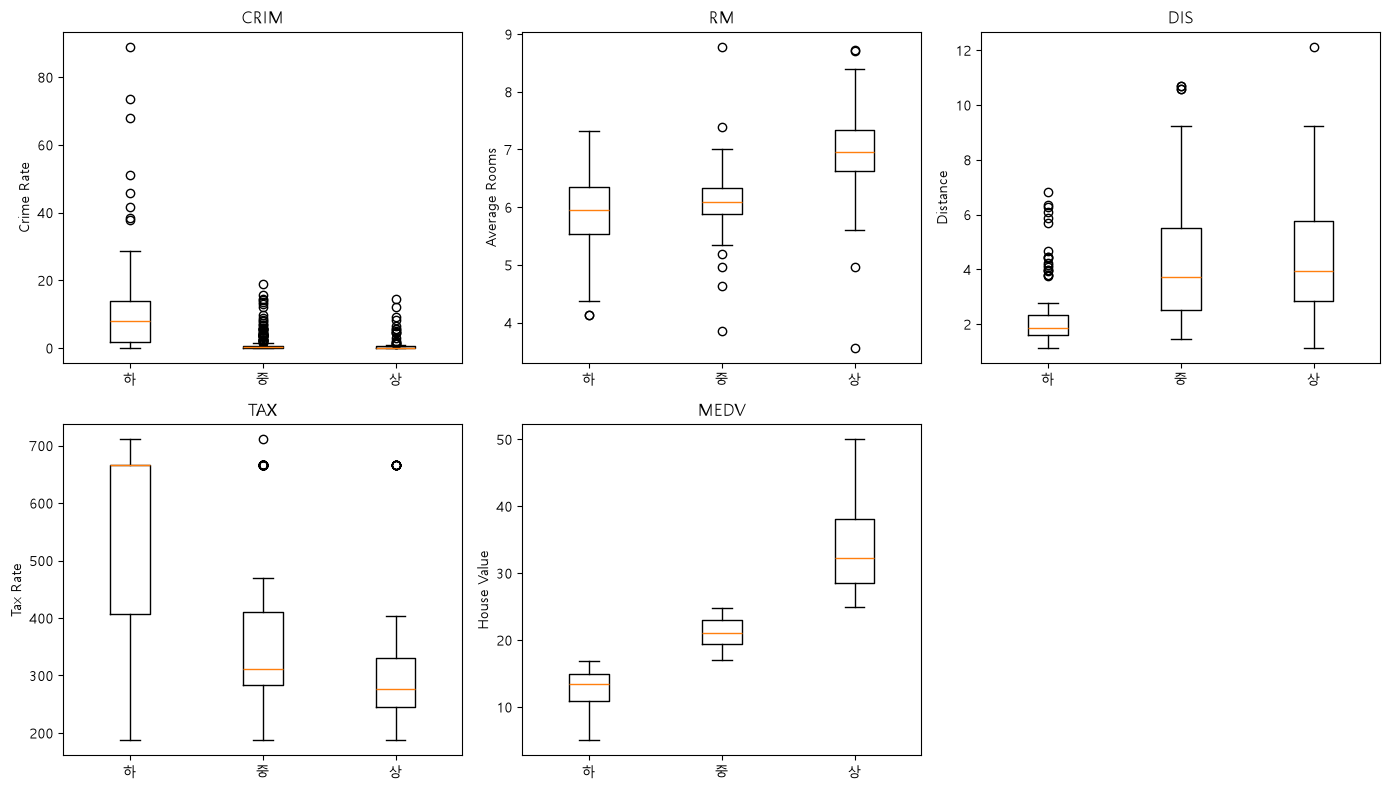

In [9]:
fig = plt.figure(figsize=(14, 8))

# 1. CRIM
axes1 = fig.add_subplot(2, 3, 1)

axes1.boxplot([
    low["crim"],
    middle["crim"],
    high["crim"]
])

axes1.set_title("CRIM")
axes1.set_xticklabels(["하", "중", "상"])
axes1.set_ylabel("Crime Rate")


# 2. RM
axes2 = fig.add_subplot(2, 3, 2)

axes2.boxplot([
    low["rm"],
    middle["rm"],
    high["rm"]
])

axes2.set_title("RM")
axes2.set_xticklabels(["하", "중", "상"])
axes2.set_ylabel("Average Rooms")


# 3. DIS
axes3 = fig.add_subplot(2, 3, 3)

axes3.boxplot([
    low["dis"],
    middle["dis"],
    high["dis"]
])

axes3.set_title("DIS")
axes3.set_xticklabels(["하", "중", "상"])
axes3.set_ylabel("Distance")


# 4. TAX
axes4 = fig.add_subplot(2, 3, 4)

axes4.boxplot([
    low["tax"],
    middle["tax"],
    high["tax"]
])

axes4.set_title("TAX")
axes4.set_xticklabels(["하", "중", "상"])
axes4.set_ylabel("Tax Rate")


# 5. MEDV
axes5 = fig.add_subplot(2, 3, 5)

axes5.boxplot([
    low["medv"],
    middle["medv"],
    high["medv"]
])

axes5.set_title("MEDV")
axes5.set_xticklabels(["하", "중", "상"])
axes5.set_ylabel("House Value")


plt.tight_layout()
plt.show()

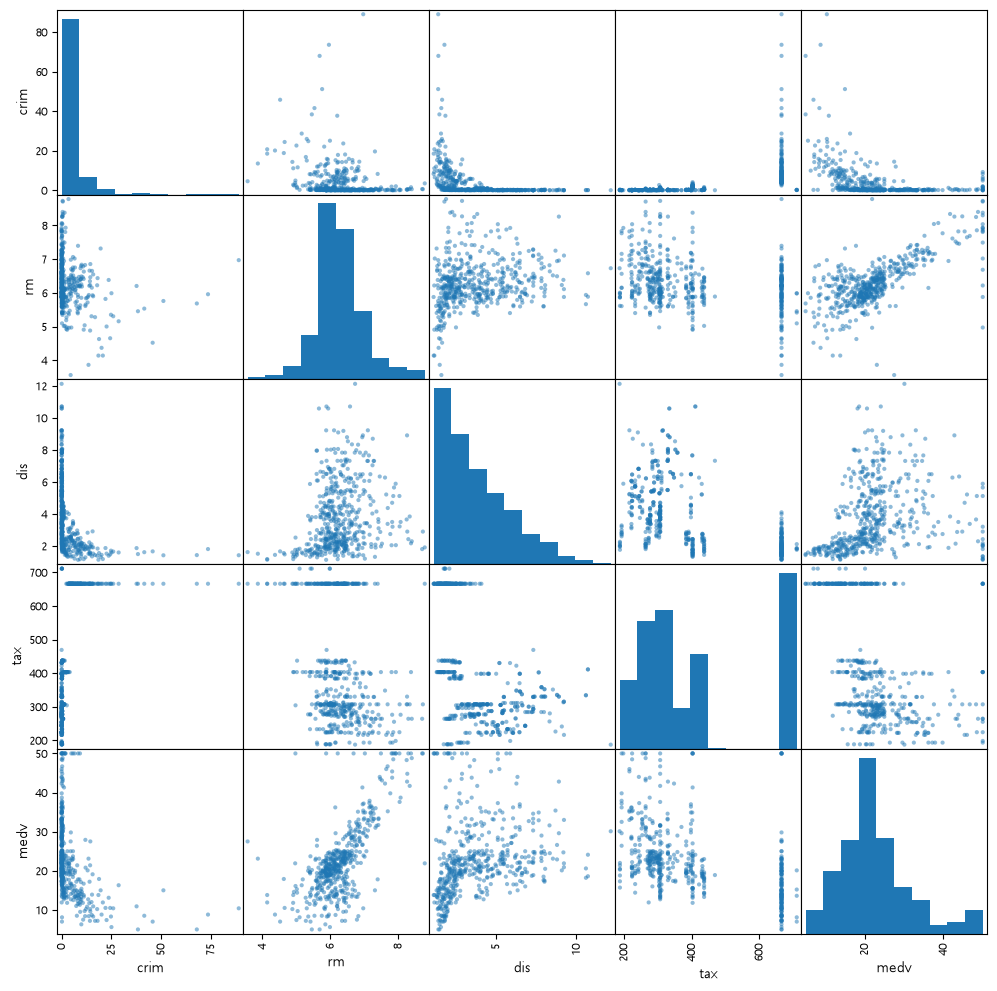

In [10]:
# [과제1] 변수들의 주택가격 상/중/하에 따른 분포 분석

from pandas.plotting import scatter_matrix

scatter_matrix(
    df2[["crim", "rm", "dis", "tax", "medv"]],
    figsize=(12, 12),
    diagonal="hist"
)

plt.show()

# 5개 변수이므로 5 × 5 = 25개의 그래프가 만들어진다.
# 대각선: 각 변수의 히스토그램
# 대각선 이외: 두 변수 간 산점도
# 따라서 변수 간 관계와 분포를 동시에 확인할 수 있다.

# RM ↔ MEDV: 양의 상관관계가 비교적 뚜렷하다. → 방 개수가 많을수록 주택가격이 높아지는 경향
# CRIM ↔ MEDV: 음의 관계가 나타난다. → 범죄율이 높을수록 주택가격이 낮아지는 경향
# DIS ↔ MEDV: 뚜렷한 선형관계는 상대적으로 약하다.
# TAX ↔ MEDV: 음의 관계가 나타나는 편이다.
# CRIM, TAX 등은 일부 극단적인 값이 있어 산점도에서 이상치도 함께 확인할 수 있다.

#              crim    rm     dis    tax    medv
#           ┌──────┬──────┬──────┬──────┬──────┐
#    crim   │ 분포 │ 관계 │ 관계 │ 관계 │ 관계 │
#    rm     │ 관계 │ 분포 │ 관계 │ 관계 │ 관계 │
#    dis    │ 관계 │ 관계 │ 분포 │ 관계 │ 관계 │
#    tax    │ 관계 │ 관계 │ 관계 │ 분포 │ 관계 │
#    medv   │ 관계 │ 관계 │ 관계 │ 관계 │ 분포 │
#           └──────┴──────┴──────┴──────┴──────┘

In [11]:
# 수치(상관계수)를 사용하여 확인
# 상관계수
# 1 에 가까움	강한 양의 상관관계
# 0 에 가까움	상관관계가 약함
# -1 에 가까움	강한 음의 상관관계

corr = df2[["crim", "rm", "dis", "tax", "medv"]].corr()

display(corr)

,crim,rm,dis,tax,medv
crim,1.000000,-0.219247,-0.379670,0.582764,-0.388305
rm,-0.219247,1.000000,0.205246,-0.292048,0.695360
dis,-0.379670,0.205246,1.000000,-0.534432,0.249929
tax,0.582764,-0.292048,-0.534432,1.000000,-0.468536
medv,-0.388305,0.695360,0.249929,-0.468536,1.000000
